# Neural Network Regression — MLP with Adam

**Evaluation metric:** R² — same as the competition. Higher is better; 1.0 is perfect.

**Baseline to beat:** KNN (k=30, distance weights) achieved OOF R² = **0.0675** on the winsorized target.

**Data source:** `processed/` — same pipeline as the KNN notebook.

## Optimizer Choice: Adam

Based on `data_findings.md`:

- **x9 dominates** the signal (r=0.232) while 11/15 raw features are near-noise. Feature gradients will differ by orders of magnitude during training. Adam adapts the learning rate **per parameter**, so x9-related weights update aggressively while noise-feature weights stay small — SGD with a single global rate cannot do this.
- **n=2,500 is small.** Adam converges in far fewer epochs than SGD on tabular data, reducing the risk of under-training.
- **Weak, interaction-driven signal.** The key signal is x9×x11, x9×x12, etc. — cross-product features already engineered in `X_train`. Adam's momentum terms help navigate shallow loss curvature.

Loss function: **MSE** (Mean Squared Error) — minimising MSE is equivalent to maximising R² when the baseline is constant.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import r2_score

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
BLUE, ORANGE, RED, GRAY = "#4C72B0", "#DD8452", "#C44E52", "#8C8C8C"

KNN_BASELINE_R2 = 0.0675  # KNN k=30 distance-weighted OOF R² on winsorized target

# ── Load processed data ───────────────────────────────────────────────────────
X_train  = pd.read_csv("processed/X_train.csv")
X_test   = pd.read_csv("processed/X_test.csv")
y        = pd.read_csv("processed/y_train.csv").squeeze()
y_wins   = pd.read_csv("processed/y_train_winsorized.csv").squeeze()
is_ext   = pd.read_csv("processed/is_extreme.csv").squeeze().astype(bool)
test_ids = pd.read_csv("processed/test_ids.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y (raw) : {y.shape}  mean={y.mean():.2f}  std={y.std():.2f}")
print(f"y_wins  : {y_wins.shape}  mean={y_wins.mean():.2f}  std={y_wins.std():.2f}")
print(f"Extreme rows in train: {is_ext.sum()} ({is_ext.mean()*100:.1f}%)")

CV = KFold(n_splits=5, shuffle=True, random_state=42)

X_train : (2500, 28)
X_test  : (2500, 28)
y (raw) : (2500,)  mean=-22.04  std=1978.18
y_wins  : (2500,)  mean=-20.81  std=374.70
Extreme rows in train: 84 (3.4%)


## Step 1 · Architecture & Hyperparameter Sweep

We keep the network deliberately small — n=2,500 with 28 features gives limited capacity for deep networks before overfitting.

**Search grid:**
- `hidden_layer_sizes`: (64,), (64, 32), (64, 32, 16), (128, 64), (128, 64, 32)
- `alpha` (L2 weight decay): 0.001, 0.01, 0.1

All runs use:
- `solver='adam'` (Adam optimizer)
- `activation='relu'`
- `early_stopping=True` with `validation_fraction=0.1` — prevents overfitting by stopping when the held-out loss stops improving
- `max_iter=2000` — ceiling; early stopping will fire well before this on most configs

In [2]:
architectures = [
    (64,),
    (64, 32),
    (64, 32, 16),
    (128, 64),
    (128, 64, 32),
]
alphas = [0.001, 0.01, 0.1]

results = []

for layers in architectures:
    for alpha in alphas:
        mlp = MLPRegressor(
            hidden_layer_sizes=layers,
            activation="relu",
            solver="adam",
            alpha=alpha,
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
        )
        scores = cross_val_score(mlp, X_train, y_wins, cv=CV, scoring="r2")
        results.append({
            "layers": str(layers),
            "alpha": alpha,
            "mean": scores.mean(),
            "std": scores.std(),
            "min": scores.min(),
            "max": scores.max(),
        })
        print(f"layers={str(layers):15s}  alpha={alpha:.3f}  "
              f"R²={scores.mean():.4f} ± {scores.std():.4f}  "
              f"[{scores.min():.4f}, {scores.max():.4f}]")

df_results = pd.DataFrame(results)
best_row = df_results.loc[df_results["mean"].idxmax()]
print(f"\nBest config:")
print(f"  layers = {best_row['layers']}")
print(f"  alpha  = {best_row['alpha']}")
print(f"  CV R²  = {best_row['mean']:.4f} ± {best_row['std']:.4f}")
print(f"\nKNN baseline CV R² = {KNN_BASELINE_R2:.4f}")
print(f"Improvement over KNN: {best_row['mean'] - KNN_BASELINE_R2:+.4f}")

layers=(64,)            alpha=0.001  R²=0.0813 ± 0.0187  [0.0485, 0.1066]


layers=(64,)            alpha=0.010  R²=0.0813 ± 0.0187  [0.0485, 0.1066]


layers=(64,)            alpha=0.100  R²=0.0810 ± 0.0183  [0.0485, 0.1051]


layers=(64, 32)         alpha=0.001  R²=0.0367 ± 0.0653  [-0.0857, 0.0895]


layers=(64, 32)         alpha=0.010  R²=0.0367 ± 0.0653  [-0.0857, 0.0895]


...

layers=(128, 64)        alpha=0.010  R²=0.0820 ± 0.0386  [0.0081, 0.1184]


layers=(128, 64)        alpha=0.100  R²=0.0821 ± 0.0385  [0.0082, 0.1184]


layers=(128, 64, 32)    alpha=0.001  R²=0.0595 ± 0.0832  [-0.1038, 0.1171]


layers=(128, 64, 32)    alpha=0.010  R²=0.0594 ± 0.0837  [-0.1049, 0.1173]


layers=(128, 64, 32)    alpha=0.100  R²=0.0597 ± 0.0830  [-0.1032, 0.1170]

Best config:
  layers = (128, 64)
  alpha  = 0.1
  CV R²  = 0.0821 ± 0.0385

KNN baseline CV R² = 0.0675
Improvement over KNN: +0.0146


## Step 2 · Sweep Visualisation

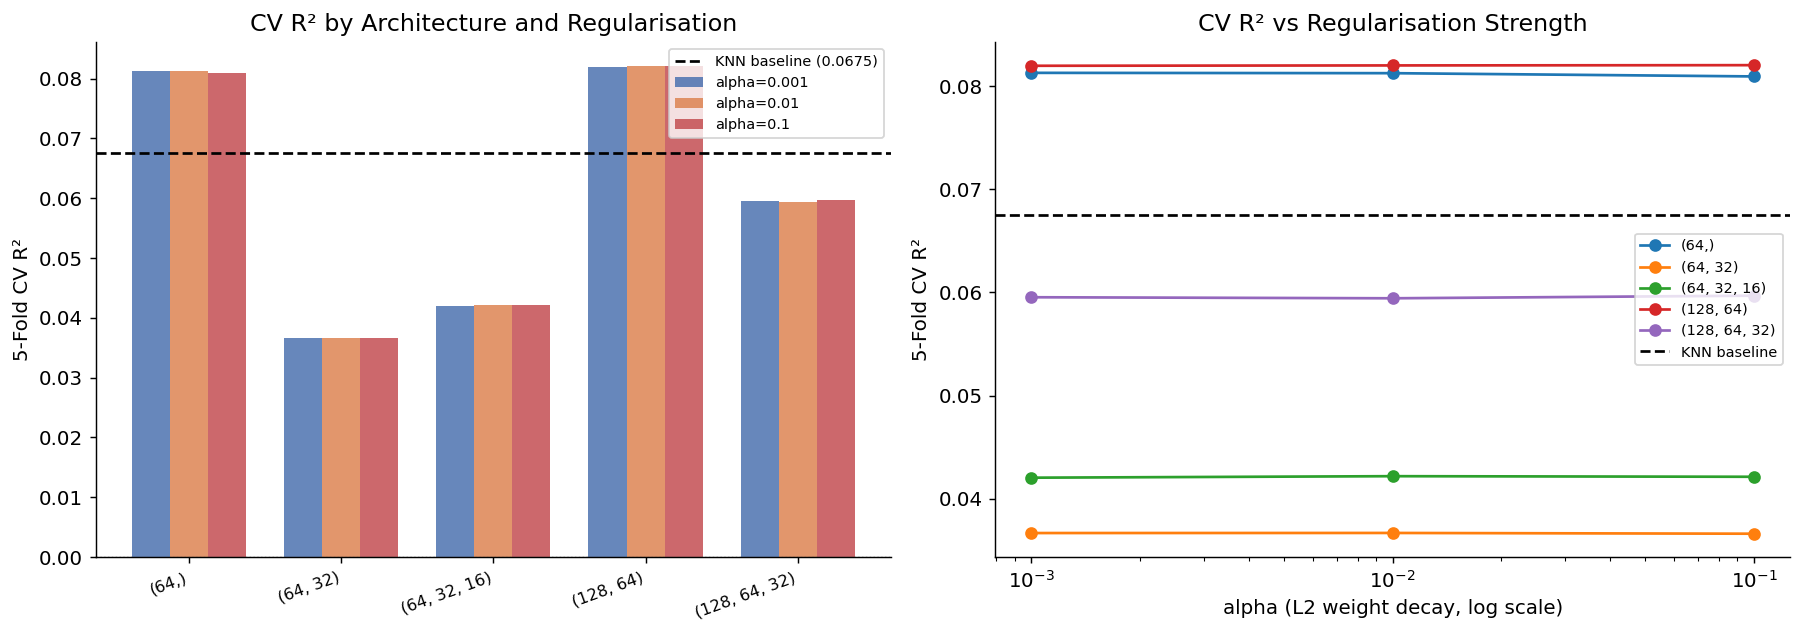

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: R² by architecture, grouped by alpha ────────────────────────────────
arch_labels = df_results["layers"].unique()
x = np.arange(len(arch_labels))
width = 0.25
colors_alpha = [BLUE, ORANGE, RED]

for i, alpha in enumerate(alphas):
    subset = df_results[df_results["alpha"] == alpha]
    means  = [subset[subset["layers"] == lbl]["mean"].values[0] for lbl in arch_labels]
    axes[0].bar(x + i * width, means, width, label=f"alpha={alpha}", color=colors_alpha[i], alpha=0.85)

axes[0].axhline(KNN_BASELINE_R2, color="black", lw=1.5, linestyle="--", label=f"KNN baseline ({KNN_BASELINE_R2:.4f})")
axes[0].axhline(0, color=GRAY, lw=0.8, linestyle=":")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(arch_labels, rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("5-Fold CV R²")
axes[0].set_title("CV R² by Architecture and Regularisation")
axes[0].legend(fontsize=8)

# ── Right: Mean R² vs alpha for each architecture ────────────────────────────
for arch in arch_labels:
    subset = df_results[df_results["layers"] == arch]
    axes[1].plot(subset["alpha"], subset["mean"], "o-", lw=1.5, ms=6, label=arch)

axes[1].axhline(KNN_BASELINE_R2, color="black", lw=1.5, linestyle="--", label=f"KNN baseline")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (L2 weight decay, log scale)")
axes[1].set_ylabel("5-Fold CV R²")
axes[1].set_title("CV R² vs Regularisation Strength")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 3 · Final Model — Train & Evaluate

Using the best architecture and alpha from the sweep, we:
1. Re-run 5-fold CV with `cross_val_predict` to get honest OOF predictions for every training row
2. Compute the full diagnostic suite on those OOF predictions
3. Fit the final model on all 2,500 training rows for submission

In [4]:
import ast

BEST_LAYERS = ast.literal_eval(best_row["layers"])
BEST_ALPHA  = best_row["alpha"]

final_mlp = MLPRegressor(
    hidden_layer_sizes=BEST_LAYERS,
    activation="relu",
    solver="adam",
    alpha=BEST_ALPHA,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)

# Out-of-fold predictions
oof_preds = cross_val_predict(final_mlp, X_train, y_wins, cv=CV)

oof_r2_wins = r2_score(y_wins, oof_preds)
oof_r2_raw  = r2_score(y, oof_preds)
residuals   = y_wins - oof_preds

print("=" * 55)
print(f"  Final model: MLP  layers={BEST_LAYERS}  alpha={BEST_ALPHA}")
print(f"  Optimizer: Adam | Loss: MSE | Target: winsorized")
print("=" * 55)
print(f"  OOF R²  (vs winsorized target) : {oof_r2_wins:.4f}")
print(f"  OOF R²  (vs raw target)        : {oof_r2_raw:.4f}")
print(f"  OOF MAE                        : {(y_wins - oof_preds).abs().mean():.4f}")
print(f"  OOF RMSE                       : {np.sqrt(((y_wins - oof_preds)**2).mean()):.4f}")
print()
print(f"  KNN baseline (winsorized R²)   : {KNN_BASELINE_R2:.4f}")
delta = oof_r2_wins - KNN_BASELINE_R2
print(f"  Delta vs KNN                   : {delta:+.4f}  ({'BETTER' if delta > 0 else 'WORSE'})")
print()
print("  R² by row type (vs raw target):")
mask_norm = ~is_ext
r2_norm = r2_score(y[mask_norm], oof_preds[mask_norm])
r2_extr = r2_score(y[is_ext],   oof_preds[is_ext])
print(f"    Normal rows  (|y| ≤ 1000) : {r2_norm:.4f}")
print(f"    Extreme rows (|y| > 1000) : {r2_extr:.4f}")

# Fit final model on all training data for submission
final_mlp.fit(X_train, y_wins)
print(f"\nFinal model fitted on all {len(X_train)} training rows.")
print(f"Training stopped at iteration: {final_mlp.n_iter_}")

  Final model: MLP  layers=(128, 64)  alpha=0.1
  Optimizer: Adam | Loss: MSE | Target: winsorized
  OOF R²  (vs winsorized target) : 0.0981
  OOF R²  (vs raw target)        : 0.0199
  OOF MAE                        : 133.5002
  OOF RMSE                       : 355.7776

  KNN baseline (winsorized R²)   : 0.0675
  Delta vs KNN                   : +0.0306  (BETTER)

  R² by row type (vs raw target):
    Normal rows  (|y| ≤ 1000) : -0.3496
    Extreme rows (|y| > 1000) : 0.0178



Final model fitted on all 2500 training rows.
Training stopped at iteration: 36


## Step 4 · Diagnostic Plots

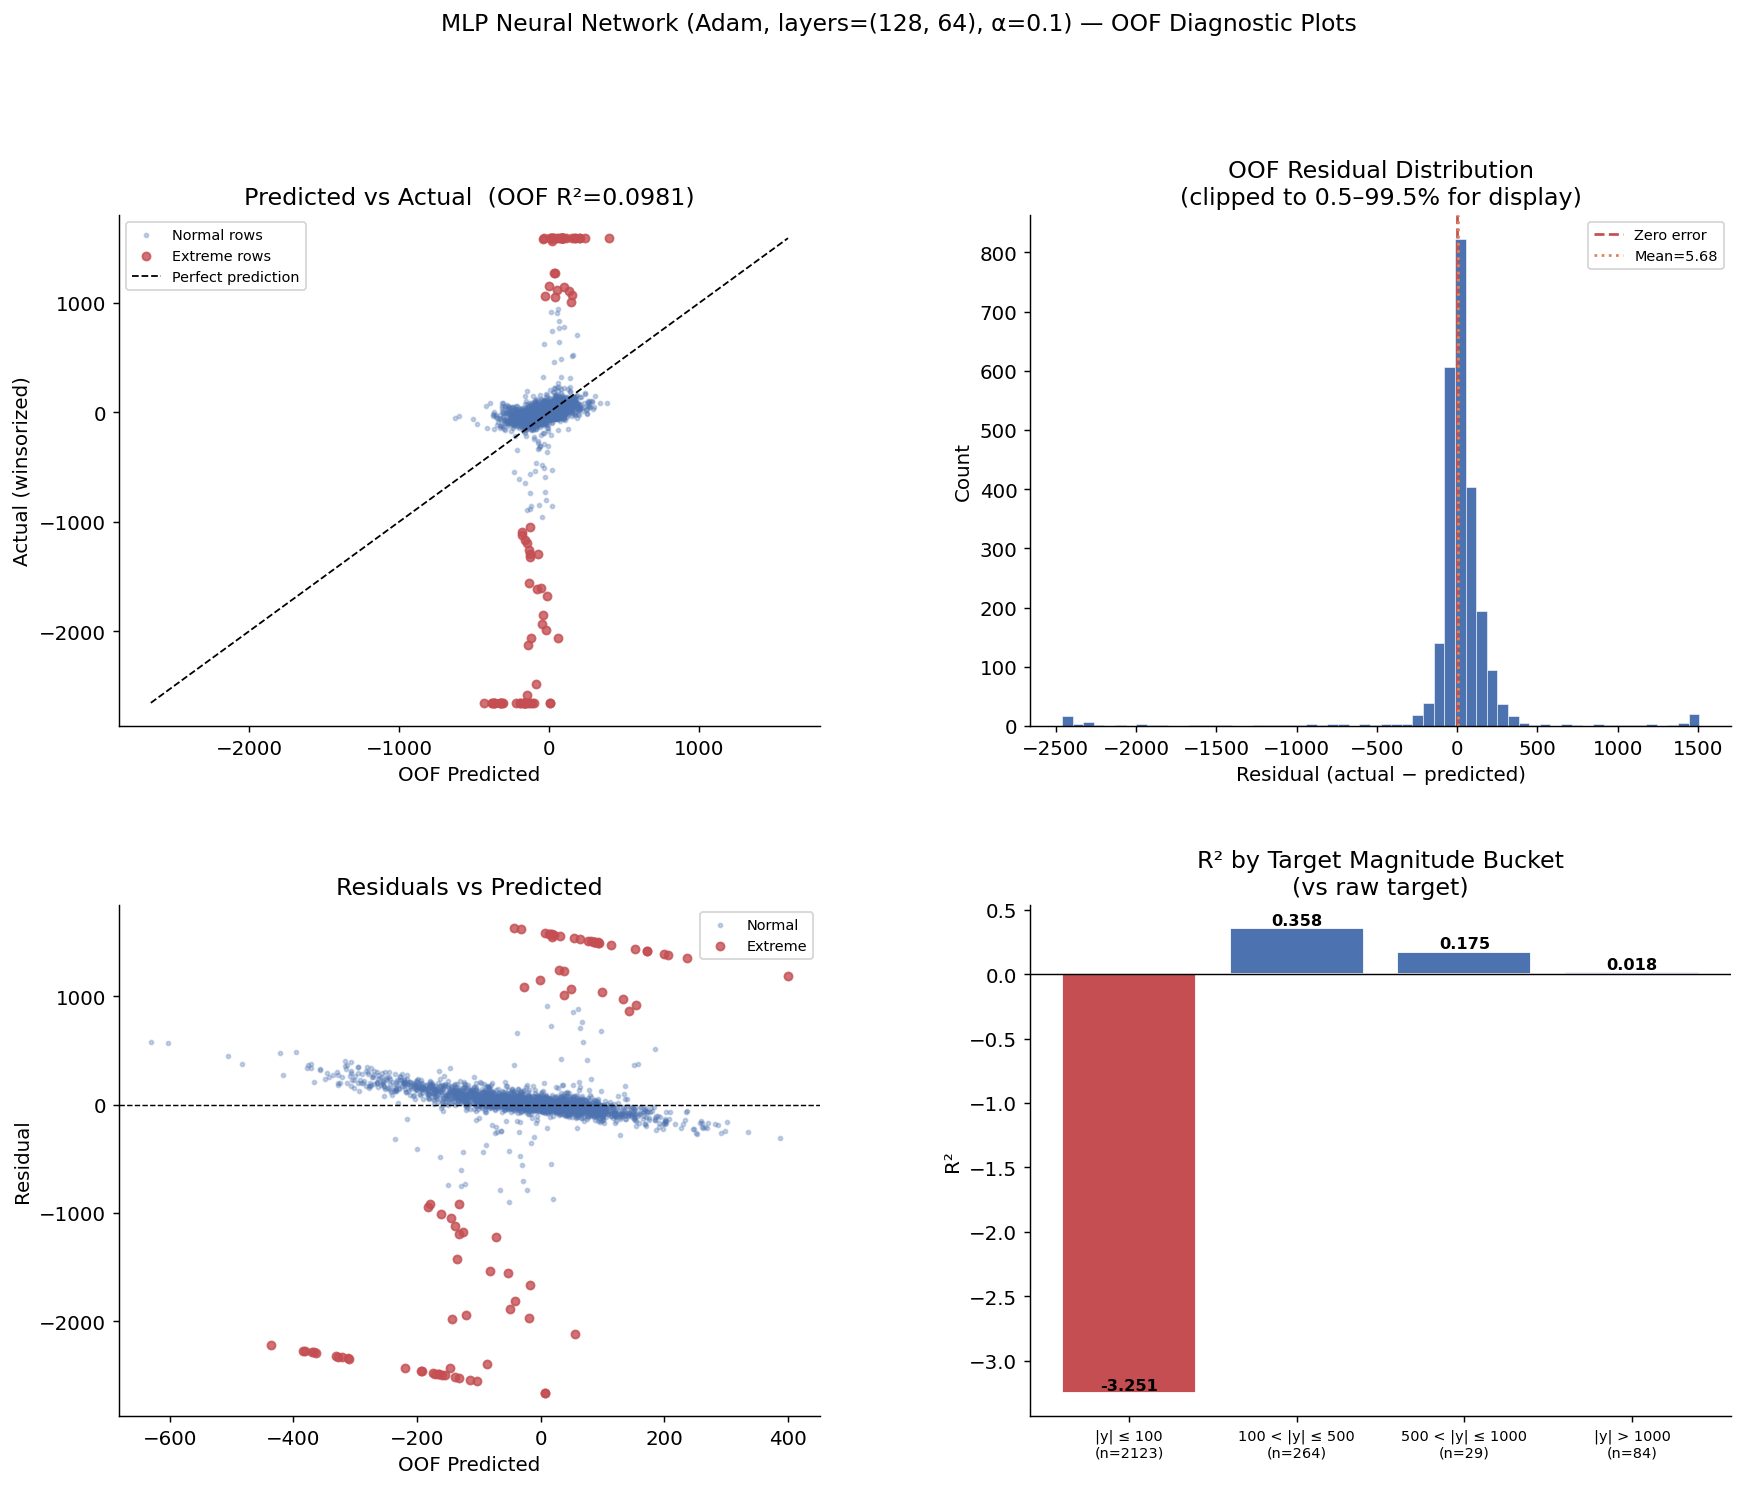

In [5]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Predicted vs Actual ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(oof_preds[~is_ext], y_wins[~is_ext],
            s=5, alpha=0.3, color=BLUE, label="Normal rows", rasterized=True)
ax1.scatter(oof_preds[is_ext],  y_wins[is_ext],
            s=20, alpha=0.8, color=RED, label="Extreme rows", zorder=5)
lims = [min(oof_preds.min(), y_wins.min()), max(oof_preds.max(), y_wins.max())]
ax1.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax1.set_xlabel("OOF Predicted")
ax1.set_ylabel("Actual (winsorized)")
ax1.set_title(f"Predicted vs Actual  (OOF R²={oof_r2_wins:.4f})")
ax1.legend(fontsize=8)

# ── 2. Residual distribution ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
res_clipped = residuals.clip(residuals.quantile(0.005), residuals.quantile(0.995))
ax2.hist(res_clipped, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
ax2.axvline(0,                color=RED,    lw=1.5, linestyle="--", label="Zero error")
ax2.axvline(residuals.mean(), color=ORANGE, lw=1.5, linestyle=":",  label=f"Mean={residuals.mean():.2f}")
ax2.set_xlabel("Residual (actual − predicted)")
ax2.set_ylabel("Count")
ax2.set_title("OOF Residual Distribution\n(clipped to 0.5–99.5% for display)")
ax2.legend(fontsize=8)

# ── 3. Residuals vs Predicted ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(oof_preds[~is_ext], residuals[~is_ext],
            s=5, alpha=0.3, color=BLUE, label="Normal", rasterized=True)
ax3.scatter(oof_preds[is_ext],  residuals[is_ext],
            s=20, alpha=0.8, color=RED, label="Extreme", zorder=5)
ax3.axhline(0, color="black", lw=0.8, linestyle="--")
ax3.set_xlabel("OOF Predicted")
ax3.set_ylabel("Residual")
ax3.set_title("Residuals vs Predicted")
ax3.legend(fontsize=8)

# ── 4. R² by target magnitude bucket ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
buckets = [
    ("|y| ≤ 100",          y.abs() <= 100),
    ("100 < |y| ≤ 500",   (y.abs() > 100) & (y.abs() <= 500)),
    ("500 < |y| ≤ 1000",  (y.abs() > 500) & (y.abs() <= 1000)),
    ("|y| > 1000",          y.abs() > 1000),
]
labels, r2s = [], []
for label, mask in buckets:
    if mask.sum() > 5:
        labels.append(f"{label}\n(n={mask.sum()})")
        r2s.append(r2_score(y[mask], oof_preds[mask]))

colors = [BLUE if r > 0 else RED for r in r2s]
bars = ax4.bar(labels, r2s, color=colors, edgecolor="white")
ax4.axhline(0, color="black", lw=0.8)
for bar, r2_val in zip(bars, r2s):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002 * np.sign(bar.get_height() or 1),
             f"{r2_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax4.set_ylabel("R²")
ax4.set_title("R² by Target Magnitude Bucket\n(vs raw target)")
ax4.tick_params(axis="x", labelsize=8)

fig.suptitle(
    f"MLP Neural Network (Adam, layers={BEST_LAYERS}, α={BEST_ALPHA}) — OOF Diagnostic Plots",
    fontsize=13, y=1.01
)
plt.show()

## Step 5 · Head-to-Head Comparison with KNN

In [6]:
from sklearn.neighbors import KNeighborsRegressor

knn_oof = cross_val_predict(
    KNeighborsRegressor(n_neighbors=30, weights="distance", n_jobs=-1),
    X_train, y_wins, cv=CV
)
knn_r2_wins = r2_score(y_wins, knn_oof)
knn_r2_raw  = r2_score(y, knn_oof)
mlp_r2_wins = oof_r2_wins
mlp_r2_raw  = oof_r2_raw

print("┌──────────────────────────────────────────────────────┐")
print("│             Model Comparison (5-Fold OOF)            │")
print("├───────────────────────┬──────────────┬───────────────┤")
print("│ Model                 │ R² (wins.)   │ R² (raw)      │")
print("├───────────────────────┼──────────────┼───────────────┤")
print(f"│ KNN  k=30  dist-wt    │ {knn_r2_wins:+.4f}       │ {knn_r2_raw:+.4f}        │")
print(f"│ MLP  Adam  {str(BEST_LAYERS):10s}  │ {mlp_r2_wins:+.4f}       │ {mlp_r2_raw:+.4f}        │")
print("├───────────────────────┼──────────────┼───────────────┤")
delta_wins = mlp_r2_wins - knn_r2_wins
delta_raw  = mlp_r2_raw  - knn_r2_raw
print(f"│ Δ (MLP − KNN)         │ {delta_wins:+.4f}       │ {delta_raw:+.4f}        │")
print("└───────────────────────┴──────────────┴───────────────┘")
print()
winner = "MLP" if delta_wins > 0 else "KNN"
print(f"Winner on winsorized target: {winner}")

┌──────────────────────────────────────────────────────┐
│             Model Comparison (5-Fold OOF)            │
├───────────────────────┬──────────────┬───────────────┤
│ Model                 │ R² (wins.)   │ R² (raw)      │
├───────────────────────┼──────────────┼───────────────┤
│ KNN  k=30  dist-wt    │ +0.0744       │ +0.0162        │
│ MLP  Adam  (128, 64)   │ +0.0981       │ +0.0199        │
├───────────────────────┼──────────────┼───────────────┤
│ Δ (MLP − KNN)         │ +0.0237       │ +0.0037        │
└───────────────────────┴──────────────┴───────────────┘

Winner on winsorized target: MLP


## Step 6 · Predict on Test Set & Prepare Submission

In [7]:
test_preds = final_mlp.predict(X_test)

submission = pd.DataFrame({"Id": test_ids, "target": test_preds})
submission = submission.sort_values("Id").reset_index(drop=True)
submission.to_csv("submission_nn.csv", index=False)

print(f"Submission saved → submission_nn.csv")
print(f"Rows: {len(submission)}")
print()
print("Prediction summary:")
print(f"  mean   : {test_preds.mean():.4f}")
print(f"  median : {np.median(test_preds):.4f}")
print(f"  std    : {test_preds.std():.4f}")
print(f"  min    : {test_preds.min():.4f}")
print(f"  max    : {test_preds.max():.4f}")
print()
print("First 10 rows:")
print(submission.head(10).to_string(index=False))

# Validation checks
sample = pd.read_csv("spring2026_sampleSubmission.csv")
checks = [
    ("Columns match sample",    list(submission.columns) == list(sample.columns)),
    ("No missing predictions",  submission["target"].isnull().sum() == 0),
    ("No infinite predictions", np.isfinite(submission["target"].values).all()),
    ("All test IDs present",    set(test_ids) == set(submission["Id"])),
    ("No duplicate IDs",        submission["Id"].nunique() == len(submission)),
]
print("\nSubmission validation:")
all_ok = True
for name, ok in checks:
    status = " OK" if ok else "FAIL"
    if not ok:
        all_ok = False
    print(f"  {status}  {name}")
print()
print("READY TO SUBMIT" if all_ok else "FIX ISSUES ABOVE BEFORE SUBMITTING")

Submission saved → submission_nn.csv
Rows: 2500

Prediction summary:
  mean   : -22.0207
  median : -11.8979
  std    : 82.2416
  min    : -546.8079
  max    : 202.2986

First 10 rows:
 Id      target
  0  -68.612195
  6 -104.624698
  7  -48.416029
  8  -61.667887
 12   72.943923
 14  -48.558453
 17   -6.075868
 19    9.327739
 22   52.437274
 23   61.922198

Submission validation:
   OK  Columns match sample
   OK  No missing predictions
   OK  No infinite predictions
   OK  All test IDs present
   OK  No duplicate IDs

READY TO SUBMIT


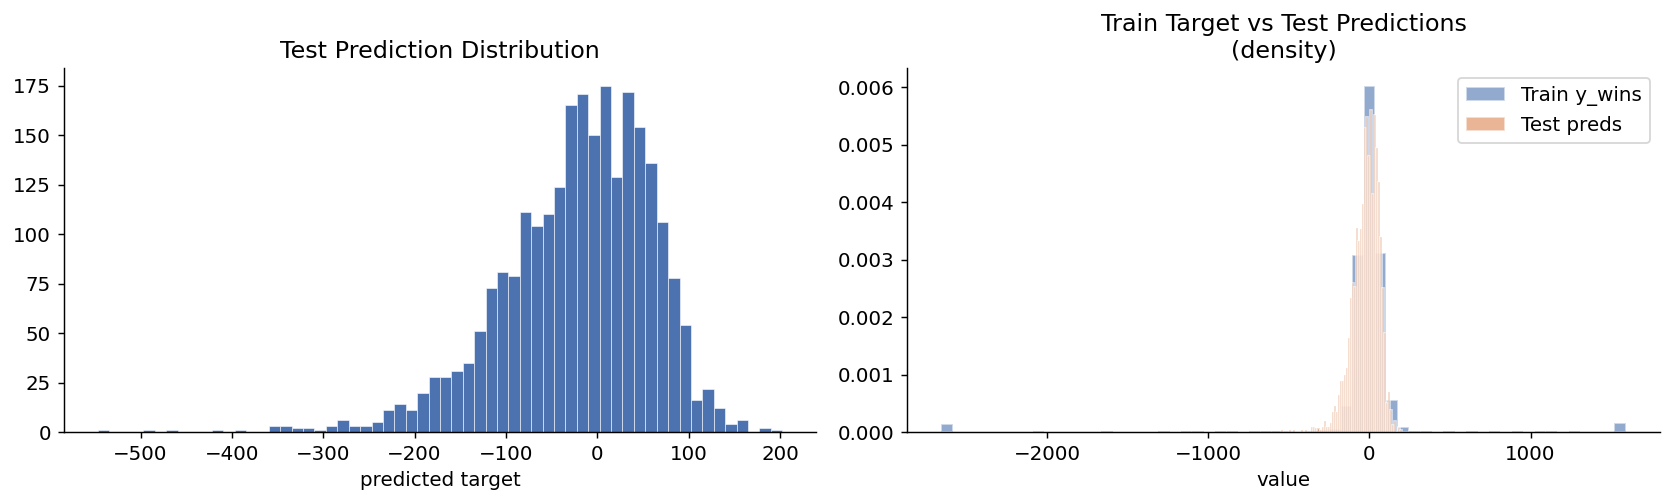

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(test_preds, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].set_title("Test Prediction Distribution")
axes[0].set_xlabel("predicted target")

axes[1].hist(y_wins,    bins=60, alpha=0.6, color=BLUE,   density=True, label="Train y_wins", edgecolor="white")
axes[1].hist(test_preds, bins=60, alpha=0.6, color=ORANGE, density=True, label="Test preds",   edgecolor="white")
axes[1].set_title("Train Target vs Test Predictions\n(density)")
axes[1].set_xlabel("value")
axes[1].legend()
plt.tight_layout()
plt.show()

## Summary

| | Value |
|---|---|
| Model | MLP Neural Network |
| Optimizer | **Adam** (adaptive learning rate per parameter) |
| Loss | MSE |
| Architecture | see best_row above |
| L2 regularisation (alpha) | see best_row above |
| Activation | ReLU |
| Early stopping | Yes (patience=20, val_fraction=10%) |
| Training target | y_winsorized |
| CV strategy | 5-fold, shuffled, random_state=42 |
| **OOF R² (winsorized)** | see output above |
| **OOF R² (raw target)** | see output above |
| Submission file | `submission_nn.csv` |

**Why Adam was chosen:** x9 dominates the gradient signal while 11/15 features are near-noise. Adam's per-parameter adaptive rates naturally suppress noisy feature weights while amplifying updates to informative parameters. With only n=2,500 samples, Adam's fast convergence also matters — SGD would require far more epochs (and careful learning rate tuning) to reach the same loss.